In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
data=pd.read_excel("Solar power generation.xlsx")
data.head()

,YEAR,MONTH,DAY,DATE,SW_IRR,WS2M,T2M,RH2M,Temp_effect,Deg_effect,final_eff,Solar_gen
0,2015,1,1,2015-01-01,3.6538,1.86,24.69,65.70,1.0,1.0,1.0,3.6538
1,2015,1,2,2015-01-02,4.2960,1.69,24.99,64.74,1.0,1.0,1.0,4.2960
2,2015,1,3,2015-01-03,4.3836,1.70,24.83,60.74,1.0,1.0,1.0,4.3836
3,2015,1,4,2015-01-04,4.6970,2.23,24.37,61.01,1.0,1.0,1.0,4.6970
4,2015,1,5,2015-01-05,4.6982,2.52,23.19,65.28,1.0,1.0,1.0,4.6982


In [4]:
data.tail()

,YEAR,MONTH,DAY,DATE,SW_IRR,WS2M,T2M,RH2M,Temp_effect,Deg_effect,final_eff,Solar_gen
4013,2025,12,27,2025-12-27,5.2262,2.51,19.65,70.24,1.0,0.965,0.965,5.043283
4014,2025,12,28,2025-12-28,5.3213,2.33,19.60,71.35,1.0,0.965,0.965,5.135054
4015,2025,12,29,2025-12-29,5.3556,2.41,20.17,73.55,1.0,0.965,0.965,5.168154
4016,2025,12,30,2025-12-30,5.2987,1.83,21.42,71.09,1.0,0.965,0.965,5.113245
4017,2025,12,31,2025-12-31,5.0477,1.21,23.13,72.68,1.0,0.965,0.965,4.871030


In [5]:
x=data[["WS2M", "T2M", "RH2M"]]
y=data["Solar_gen"]

In [6]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.3, shuffle=False)

In [7]:
rf=RandomForestRegressor(n_estimators=800, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf=rf.predict(x_test)
print("R2 Score for Random Forest:", r2_score(y_test, y_pred_rf))
print("MSE for Random forest:", mean_squared_error(y_test, y_pred_rf))

R2 Score for Random Forest: 0.523112037258457
MSE for Random forest: 0.6926906026802251


In [8]:
xgb=XGBRegressor(n_estimators=60, learning_rate=0.1)
xgb.fit(x_train,y_train)
y_pred_xgb=xgb.predict(x_test)
print("R2 Score for XGBoost:", r2_score(y_test, y_pred_xgb))
print("MSE for XGBoost:", mean_squared_error(y_test, y_pred_xgb))

R2 Score for XGBoost: 0.5275229302691278
MSE for XGBoost: 0.6862836803491292


In [9]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    
    "RMSE": [
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb)
    ],
    "R2": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})
results

,Model,RMSE,R2
0,Random Forest,0.692691,0.523112
1,XGBoost,0.686284,0.527523


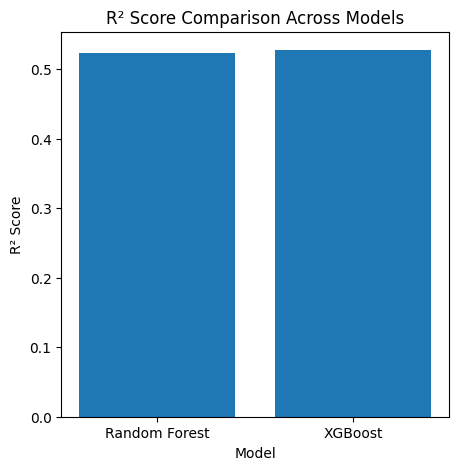

In [10]:
plt.figure(figsize=(5,5))
plt.bar(results["Model"], results["R2"])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison Across Models")
plt.xticks(rotation=0)
plt.show()

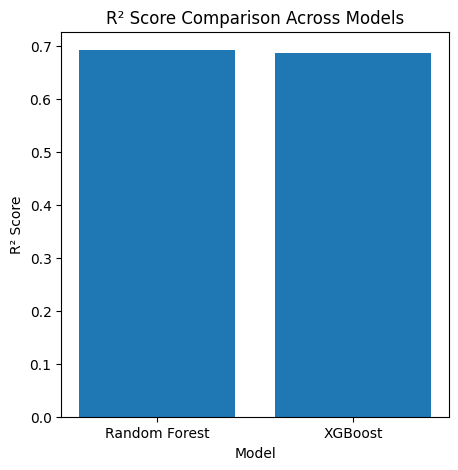

In [12]:
plt.figure(figsize=(5,5))
plt.bar(results["Model"], results["RMSE"])
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison Across Models")
plt.xticks(rotation=0)
plt.show()